In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [4]:
data = np.load("/content/PEMS08.npz")["data"].astype(np.float32)

SENSORS = data.shape[1]
data = data[:,:,0]

In [5]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)


In [6]:
SEQ_LEN = 96
PRED_LEN = 12

def create_sequences(data):
    X,Y = [],[]
    for i in range(len(data)-SEQ_LEN-PRED_LEN):
        X.append(data[i:i+SEQ_LEN])
        Y.append(data[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN])
    return np.array(X), np.array(Y)

X,Y = create_sequences(data)


In [7]:
class TrafficDataset(Dataset):
    def __init__(self,X,Y):
        self.X = torch.tensor(X).float()
        self.Y = torch.tensor(Y).float()
    def __len__(self):
        return len(self.X)
    def __getitem__(self,i):
        return self.X[i],self.Y[i]

dataset = TrafficDataset(X,Y)


In [8]:
split = int(0.8*len(dataset))

train_set = torch.utils.data.Subset(dataset, range(split))
val_set   = torch.utils.data.Subset(dataset, range(split,len(dataset)))

train_loader = DataLoader(train_set,batch_size=32,shuffle=True)
val_loader   = DataLoader(val_set,batch_size=32)


In [9]:
class CNN_LLM_PRO(nn.Module):
    def __init__(self,sensors,pred_len):
        super().__init__()

        hidden = 128

        # deep spatial CNN
        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,128,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,128,3,padding=1),
            nn.ReLU()
        )

        self.project = nn.Linear(sensors*128, hidden)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=8,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer,num_layers=8)

        self.attn = nn.MultiheadAttention(hidden,8,batch_first=True)

        self.temporal_conv = nn.Conv1d(hidden,hidden,3,padding=1)

        self.fc = nn.Linear(hidden,sensors*pred_len)

        self.pred_len = pred_len
        self.sensors = sensors

    def forward(self,x):
        x = x.unsqueeze(1)
        x = self.cnn(x)

        B,C,T,S = x.shape
        x = x.permute(0,2,1,3).reshape(B,T,-1)

        x = self.project(x)

        x = self.transformer(x)

        attn_out,_ = self.attn(x,x,x)
        x = x + attn_out

        x = x.permute(0,2,1)
        x = self.temporal_conv(x)
        x = x.permute(0,2,1)

        out = self.fc(x[:,-1,:])
        return out.reshape(B,self.pred_len,self.sensors)


In [10]:
device = "cuda"

model = CNN_LLM_PRO(SENSORS,PRED_LEN).to(device)

optimizer = torch.optim.Adam(model.parameters(),lr=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,patience=3)
loss_fn = nn.HuberLoss()


In [11]:
best_val = 1e9
patience = 8
counter = 0

for epoch in range(80):

    model.train()
    train_loss = 0

    for x,y in train_loader:
        x,y = x.to(device),y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred,y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device),y.to(device)
            pred = model(x)
            val_loss += loss_fn(pred,y).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(epoch,train_loss,val_loss)

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        torch.save(model.state_dict(),"best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


0 0.013101765219445198 0.004480812561211621
1 0.0042987865000451405 0.0037270568805192975
2 0.003262786511940093 0.0030734724824543337
3 0.0027248673980032 0.002816698337728913
4 0.0024220810026907872 0.002546054595580056
5 0.002154816946000079 0.0026251231912766825
6 0.001972442030327747 0.0024374004378432393
7 0.001826129798926329 0.0023663288655141283
8 0.0017130859544907638 0.0023873288133013826
9 0.001643529672307793 0.0022604521733670924
10 0.00155029067694134 0.0022784723797477447
11 0.0015169239869374815 0.00230308989039832
12 0.001458033860864554 0.0022457211974773322
13 0.0014292567190693204 0.002286587911028717
14 0.0013654123019502574 0.002260828273253398
15 0.0013238434997850793 0.002221745300958319
16 0.001314331211835599 0.0022834009241295963
17 0.001288841911151099 0.002195336113931393
18 0.0012479535443498543 0.0022109502785931435
19 0.0012333692948969484 0.002201498536443388
20 0.0012174711649480217 0.0021320856433269474
21 0.001184596221391657 0.0022144215795010126
2

In [12]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

preds, actual = [], []

with torch.no_grad():
    for x,y in val_loader:
        x = x.to(device)
        p = model(x).cpu().numpy()
        preds.append(p)
        actual.append(y.numpy())

preds = np.concatenate(preds)
actual = np.concatenate(actual)

preds_denorm = scaler.inverse_transform(preds.reshape(-1, preds.shape[-1])).reshape(preds.shape)
actual_denorm = scaler.inverse_transform(actual.reshape(-1, actual.shape[-1])).reshape(actual.shape)

mae  = np.mean(np.abs(preds_denorm - actual_denorm))
rmse = np.sqrt(np.mean((preds_denorm - actual_denorm)**2))

mape = np.mean(
    np.abs((actual_denorm - preds_denorm) / (actual_denorm + 1e-5))
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)


MAE : 19.785845
RMSE: 31.382877
MAPE: 339719.7


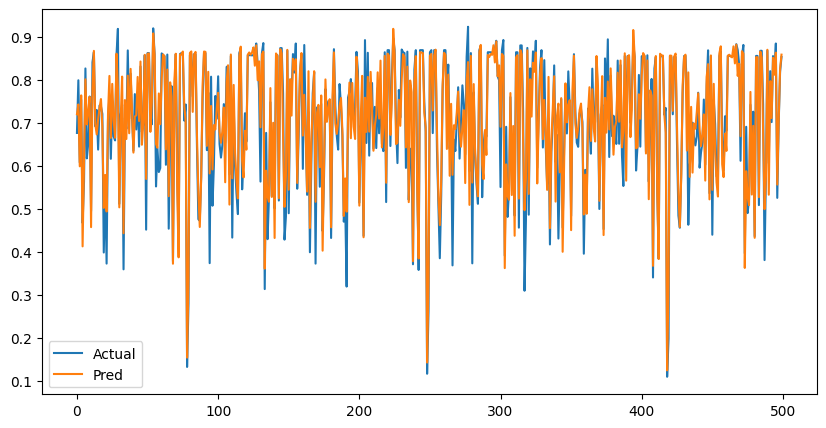

In [13]:
plt.figure(figsize=(10,5))
plt.plot(actual.flatten()[:500],label="Actual")
plt.plot(preds.flatten()[:500],label="Pred")
plt.legend()
plt.show()


In [14]:
torch.save({
    'model': model.state_dict(),
    'scaler': scaler
}, "checkpoint.pt")
